# Features that split classes

After the first round of model analysis, I found that some models return vary high values of ROC-AUC, which suggests that there are features that splits the classes well. In this notebook I try to identify those features by examining the roc-auc value between the feature values and the target directly.

In [1]:
import sys
sys.path.insert(1, '../../')

In [2]:
import zipfile
from io import BytesIO
from urllib.request import urlopen

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from feature_engine.encoding import OrdinalEncoder
from feature_engine.imputation import EndTailImputer, CategoricalImputer
from feature_engine.selection import DropConstantFeatures

from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score

from ucimlrepo import fetch_ucirepo

from functions.data import DATASETS_LS, load_dataset

warnings.filterwarnings("ignore", message="Could not infer format")

In [3]:
datasets = {
    "diabetes130": 296, 
    "default_credit": 350, 
    "htru2": 372,
    "credit_fraud":1597,
    "sencom": None,
}

def load_data(dataset):
    if dataset == "credit_fraud":
        data = fetch_openml(data_id=1597, as_frame=True)
        X = data.data.copy()
        y = data.target.copy().astype(int)
        
    elif dataset == "sencom":
        # SECOM is not available through the ucimlrepo API, so we download it
        #  directly from the UCI static file server.
        SECOM_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
        with urlopen(SECOM_URL) as resp:
            archive = zipfile.ZipFile(BytesIO(resp.read()))
        with archive.open("secom.data") as f:
            X = pd.read_csv(f, sep=r"\s+", header=None, na_values="NaN")
        with archive.open("secom_labels.data") as f:
            labels = pd.read_csv(f, sep=r"\s+", header=None)
        X.columns = [f"feature_{i}" for i in range(X.shape[1])]
        y = labels.iloc[:, 0]  # -1 = pass, 1 = fail; timestamp column is dropped

        X = EndTailImputer(imputation_method="max", fold=3).fit_transform(X)
        X = DropConstantFeatures().fit_transform(X)

    else:
        data = fetch_ucirepo(id=datasets[dataset])
        X = data.data.features.copy()
        y = data.data.targets.copy()

    if dataset == "diabetes130":
        diag_cols = ["diag_1", "diag_2", "diag_3"]

        # Create new columns to capture non-numeric values
        for col in diag_cols:
            numeric_converted = pd.to_numeric(X[col], errors='coerce')
            non_numeric_mask = numeric_converted.isnull() & X[col].notna()
            
            # New variable: non-numeric values only (numerical become NaN)
            X[f"{col}_categorical"] = X[col].where(non_numeric_mask, other=None)
            
            # Original variable: replace non-numeric with NaN
            X[col] = numeric_converted
        
        X = EndTailImputer(imputation_method="max", fold=3).fit_transform(X)
        X = CategoricalImputer().fit_transform(X)
        X = OrdinalEncoder(encoding_method="arbitrary").fit_transform(X)
        X = DropConstantFeatures().fit_transform(X)
        y = (y.iloc[:, 0] == "<30").astype(int).to_numpy()
    
    return X, y

In [4]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

for dataset in DATASETS_LS:
    X_train, X_test, y_train, y_test = load_dataset(dataset)

    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if len(good_features) > 0:
        print(f"{dataset}.")

arrhythmia.
protein_homo.
sick_euthyroid.
thyroid_sick.
us_crime.
dermatology-6.
kddcup-buffer_overflow_vs_back.
kr-vs-k-one_vs_fifteen.
page-blocks-1-3_vs_4.
shuttle-2_vs_5.


In [5]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

for dataset in datasets.keys():
    X, y = load_data(dataset)
    good_features = []
    for j in range(X.shape[1]):
        col = X.iloc[:, j] if hasattr(X, "iloc") else X[:, j]
        auc = roc_auc_score(y, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X.columns[j] if hasattr(X, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if len(good_features) > 0:
        print(f"{dataset}")

/Users/soledadgalli/Documents/repositories/env/undersampling/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


htru2
credit_fraud


In [6]:
datasets_ls = [
    "arrhythmia",
    "protein_homo",
    "sick_euthyroid",
    "thyroid_sick",
    "us_crime",
    "dermatology-6",
    "kddcup-buffer_overflow_vs_back",
    "kr-vs-k-one_vs_fifteen",
    "page-blocks-1-3_vs_4",
    "shuttle-2_vs_5",
    "htru2",
    "credit_fraud",
]

## Find features that split classes perfectly

In [7]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

for dataset in datasets_ls:
    if dataset in datasets.keys():
        X, y = load_data(dataset)
    else:
        X, _, y, _ = load_dataset(dataset)

    print(f"\n{dataset}:")

    good_features = []
    for j in range(X.shape[1]):
        col = X.iloc[:, j] if hasattr(X, "iloc") else X[:, j]
        auc = roc_auc_score(y, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X.columns[j] if hasattr(X, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if good_features:
        for feat, auc in sorted(good_features, key=lambda x: x[1], reverse=True):
            print(f"  Feature {feat}: AUC = {auc}")


arrhythmia:
  Feature x13: AUC = 0.982

protein_homo:
  Feature 52: AUC = 0.943
  Feature 54: AUC = 0.938
  Feature 4: AUC = 0.927
  Feature 2: AUC = 0.919
  Feature 57: AUC = 0.914
  Feature 34: AUC = 0.911

sick_euthyroid:
  Feature 30: AUC = 0.911

thyroid_sick:
  Feature x36: AUC = 0.928

us_crime:
  Feature 44: AUC = 0.904

dermatology-6:
  Feature 30: AUC = 1.0
  Feature 6: AUC = 0.995
  Feature 33: AUC = 0.983
  Feature 29: AUC = 0.953

kddcup-buffer_overflow_vs_back:
  Feature 2: AUC = 1.0
  Feature 4: AUC = 1.0
  Feature 35: AUC = 0.996
  Feature 31: AUC = 0.995
  Feature 5: AUC = 0.993
  Feature 32: AUC = 0.987
  Feature 23: AUC = 0.903

kr-vs-k-one_vs_fifteen:
  Feature 5: AUC = 0.973
  Feature 1: AUC = 0.926
  Feature 4: AUC = 0.912

page-blocks-1-3_vs_4:
  Feature 0: AUC = 0.946
  Feature 9: AUC = 0.943
  Feature 8: AUC = 0.931
  Feature 7: AUC = 0.923

shuttle-2_vs_5:
  Feature 6: AUC = 1.0
  Feature 0: AUC = 0.999
  Feature 1: AUC = 0.994
  Feature 2: AUC = 0.962

htru2

These 3 datasets have features that split classes perfectly:
    
- dermatology-6
- kddcup-buffer_overflow_vs_back
- shuttle-2_vs_5

These 2 datasets have features with almost perfect separation in the test set:

- arrhythmia
- kr-vs-k-one_vs_fifteen:

> ⚠️ **Conclusion**: Some datasets contain features that already separate the two classes almost perfectly (AUC ≥ 0.90). Training models on these datasets is redundant — if a single raw feature does the job, there is no need for a complex classifier. **These datasets will be removed from the analysis.**

In [8]:
# Datasets to remove from the analysis:

datasets = [
    "dermatology-6",
    "arrhythmia",
    "kddcup-buffer_overflow_vs_back",
    "kr-vs-k-one_vs_fifteen",
    "shuttle-2_vs_5",
]

## Plot features that split classes 

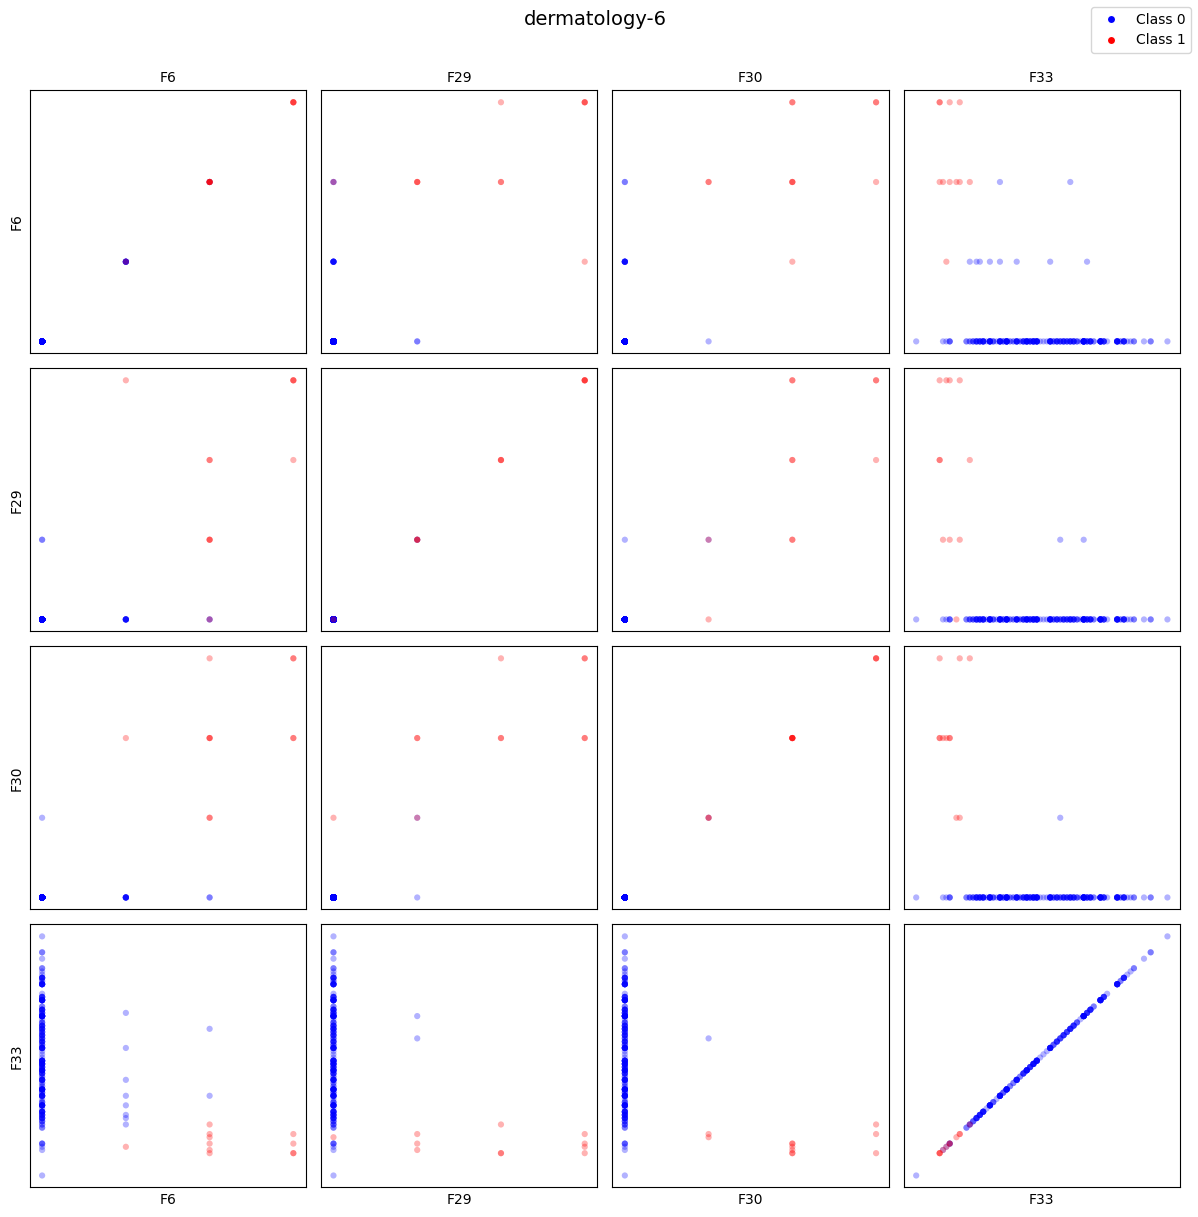

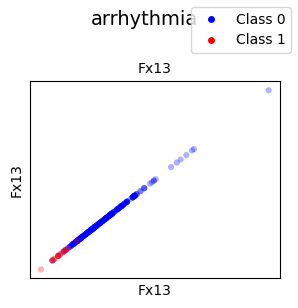

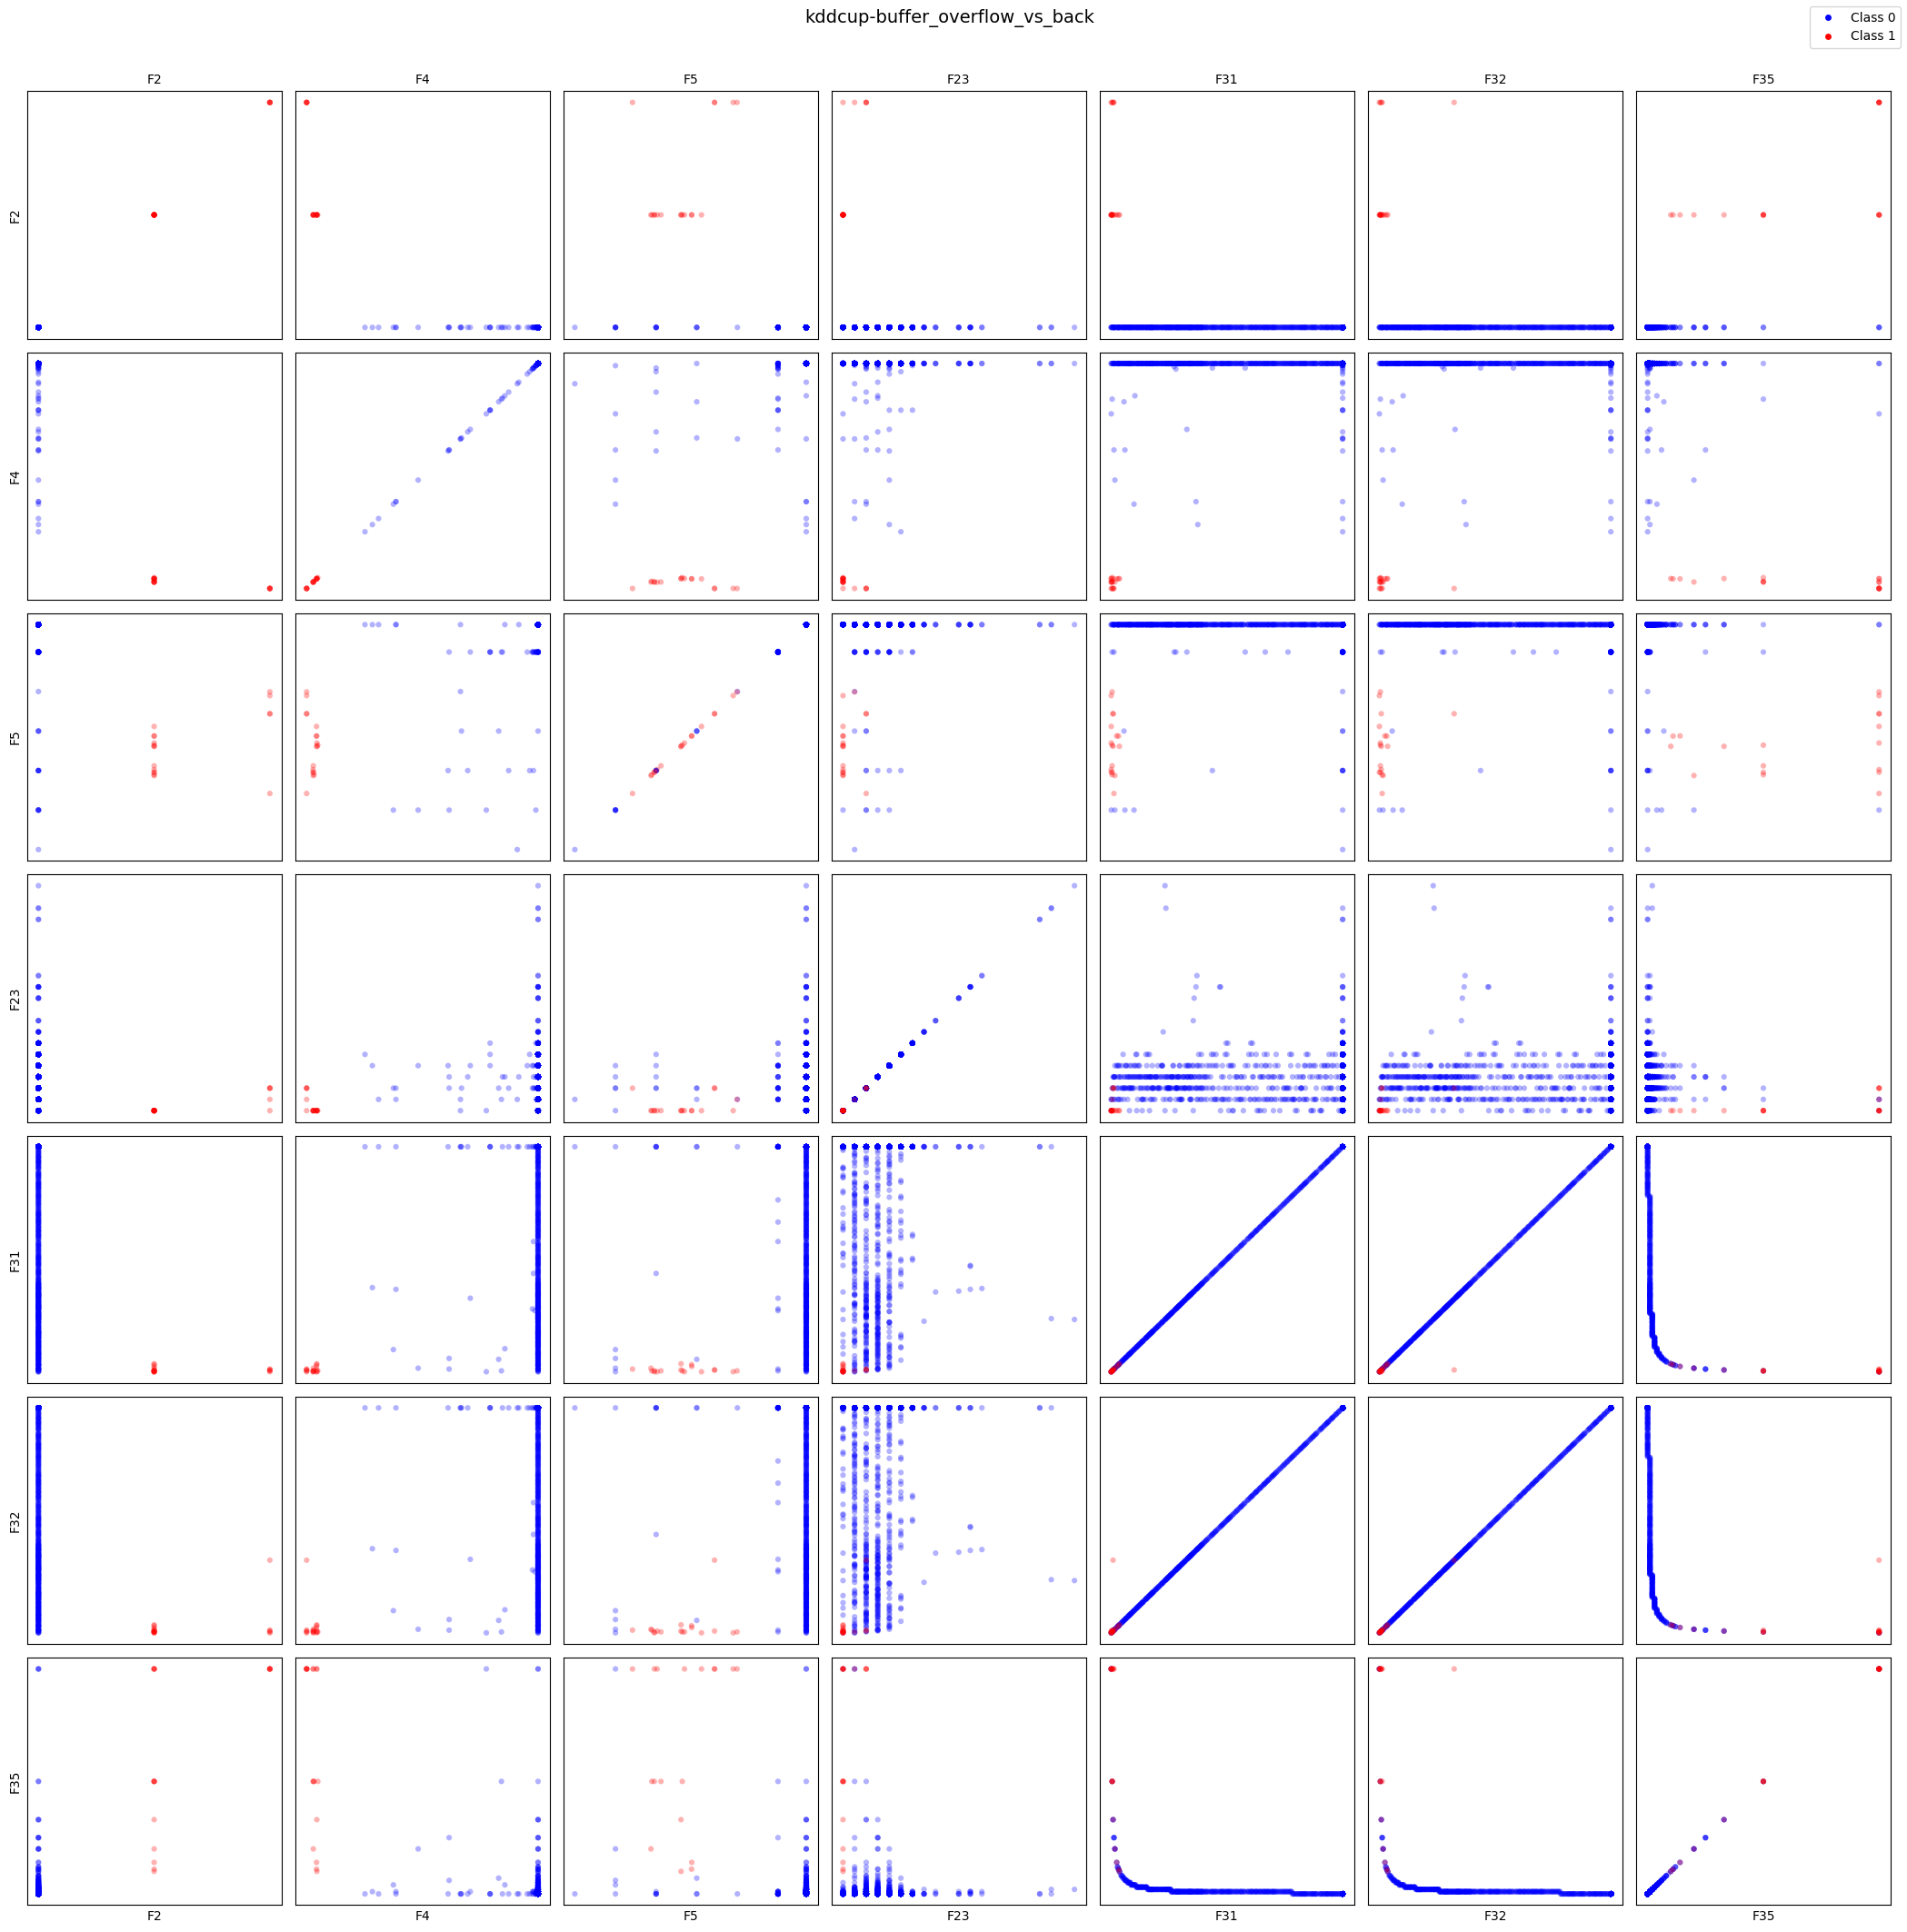

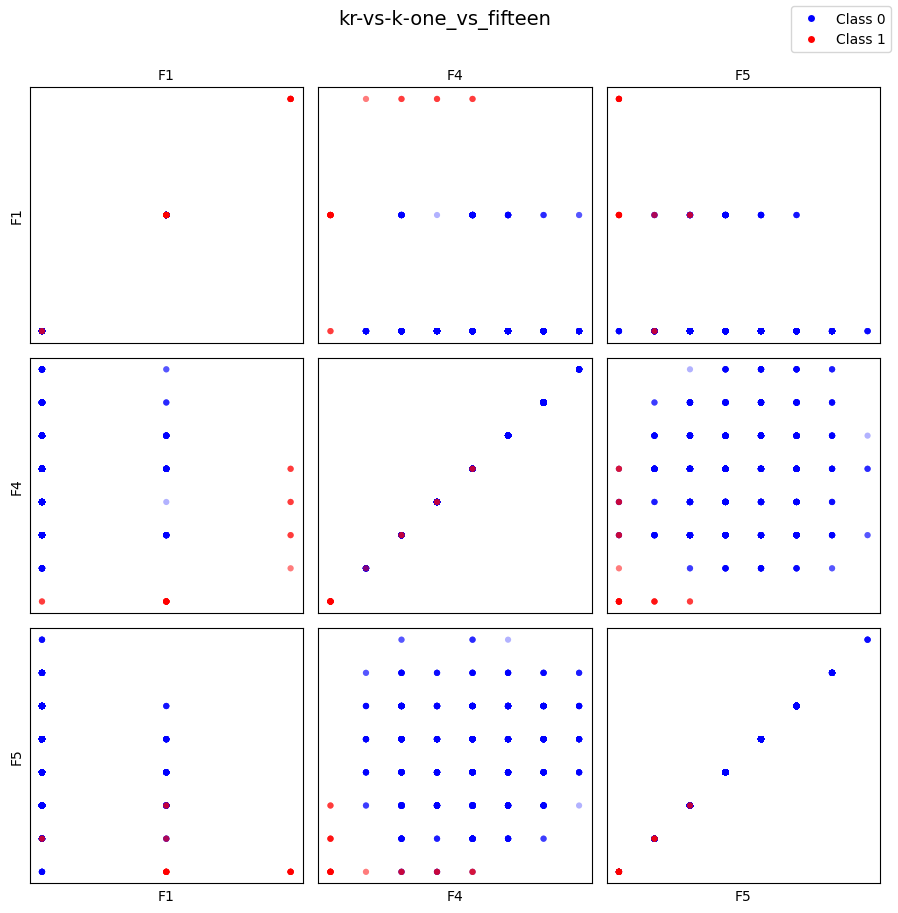

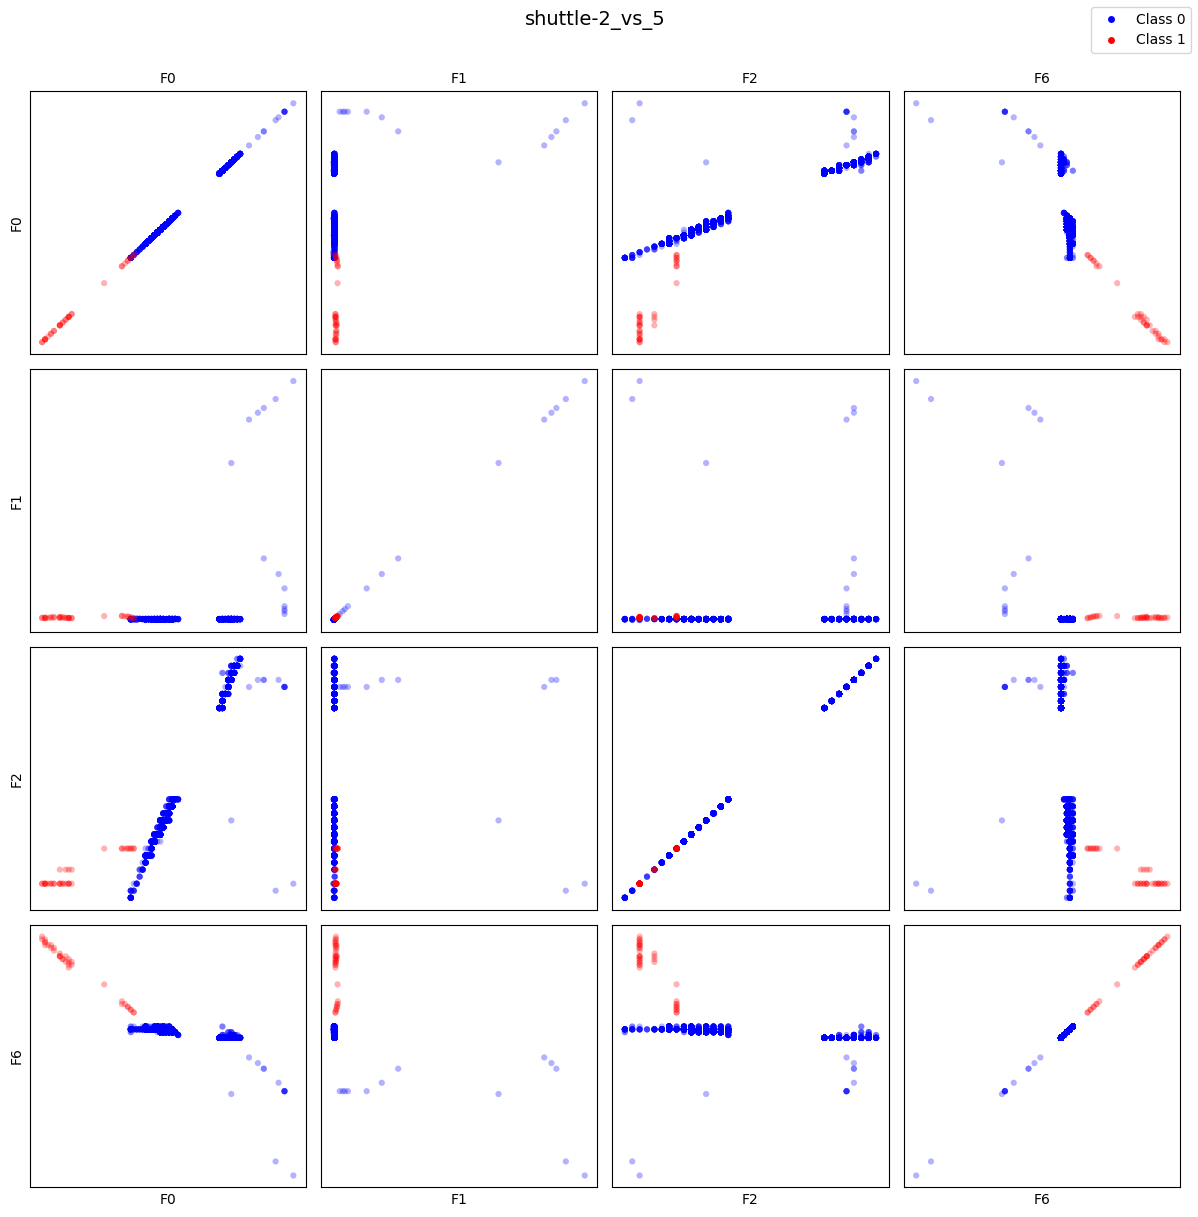

In [9]:
for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    
    # find good features
    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    if not good_features:
        print(f"{dataset}: no good features, skipping.")
        continue

    # Scatter plots
    feat_names = [f[0] for f in good_features]
    n = len(feat_names)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])
    for i, fi in enumerate(feat_names):
        for j, fj in enumerate(feat_names):
            ax = axes[i, j]
            for label, color in zip([0, 1], ["blue", "red"]):
                mask = y_train == label
                xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
                xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
                ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
            if i == n - 1:
                ax.set_xlabel(f"F{fj}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"F{fi}", fontsize=10)
            if i == 0:
                ax.set_title(f"F{fj}", fontsize=10)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
               for l, c in zip([0, 1], ["blue", "red"])]
    fig.legend(handles=handles, loc="upper right", fontsize=10)
    plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

In [10]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

datasets = ["protein_homo"]

for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    print(f"\n{dataset}:")

    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if good_features:
        for feat, auc in sorted(good_features, key=lambda x: x[1], reverse=True):
            print(f"  Feature {feat}: AUC = {auc}")
    else:
        print("  No features with near-perfect separation found.")


protein_homo:
  Feature 52: AUC = 0.943
  Feature 54: AUC = 0.938
  Feature 4: AUC = 0.927
  Feature 2: AUC = 0.919
  Feature 57: AUC = 0.914
  Feature 34: AUC = 0.911


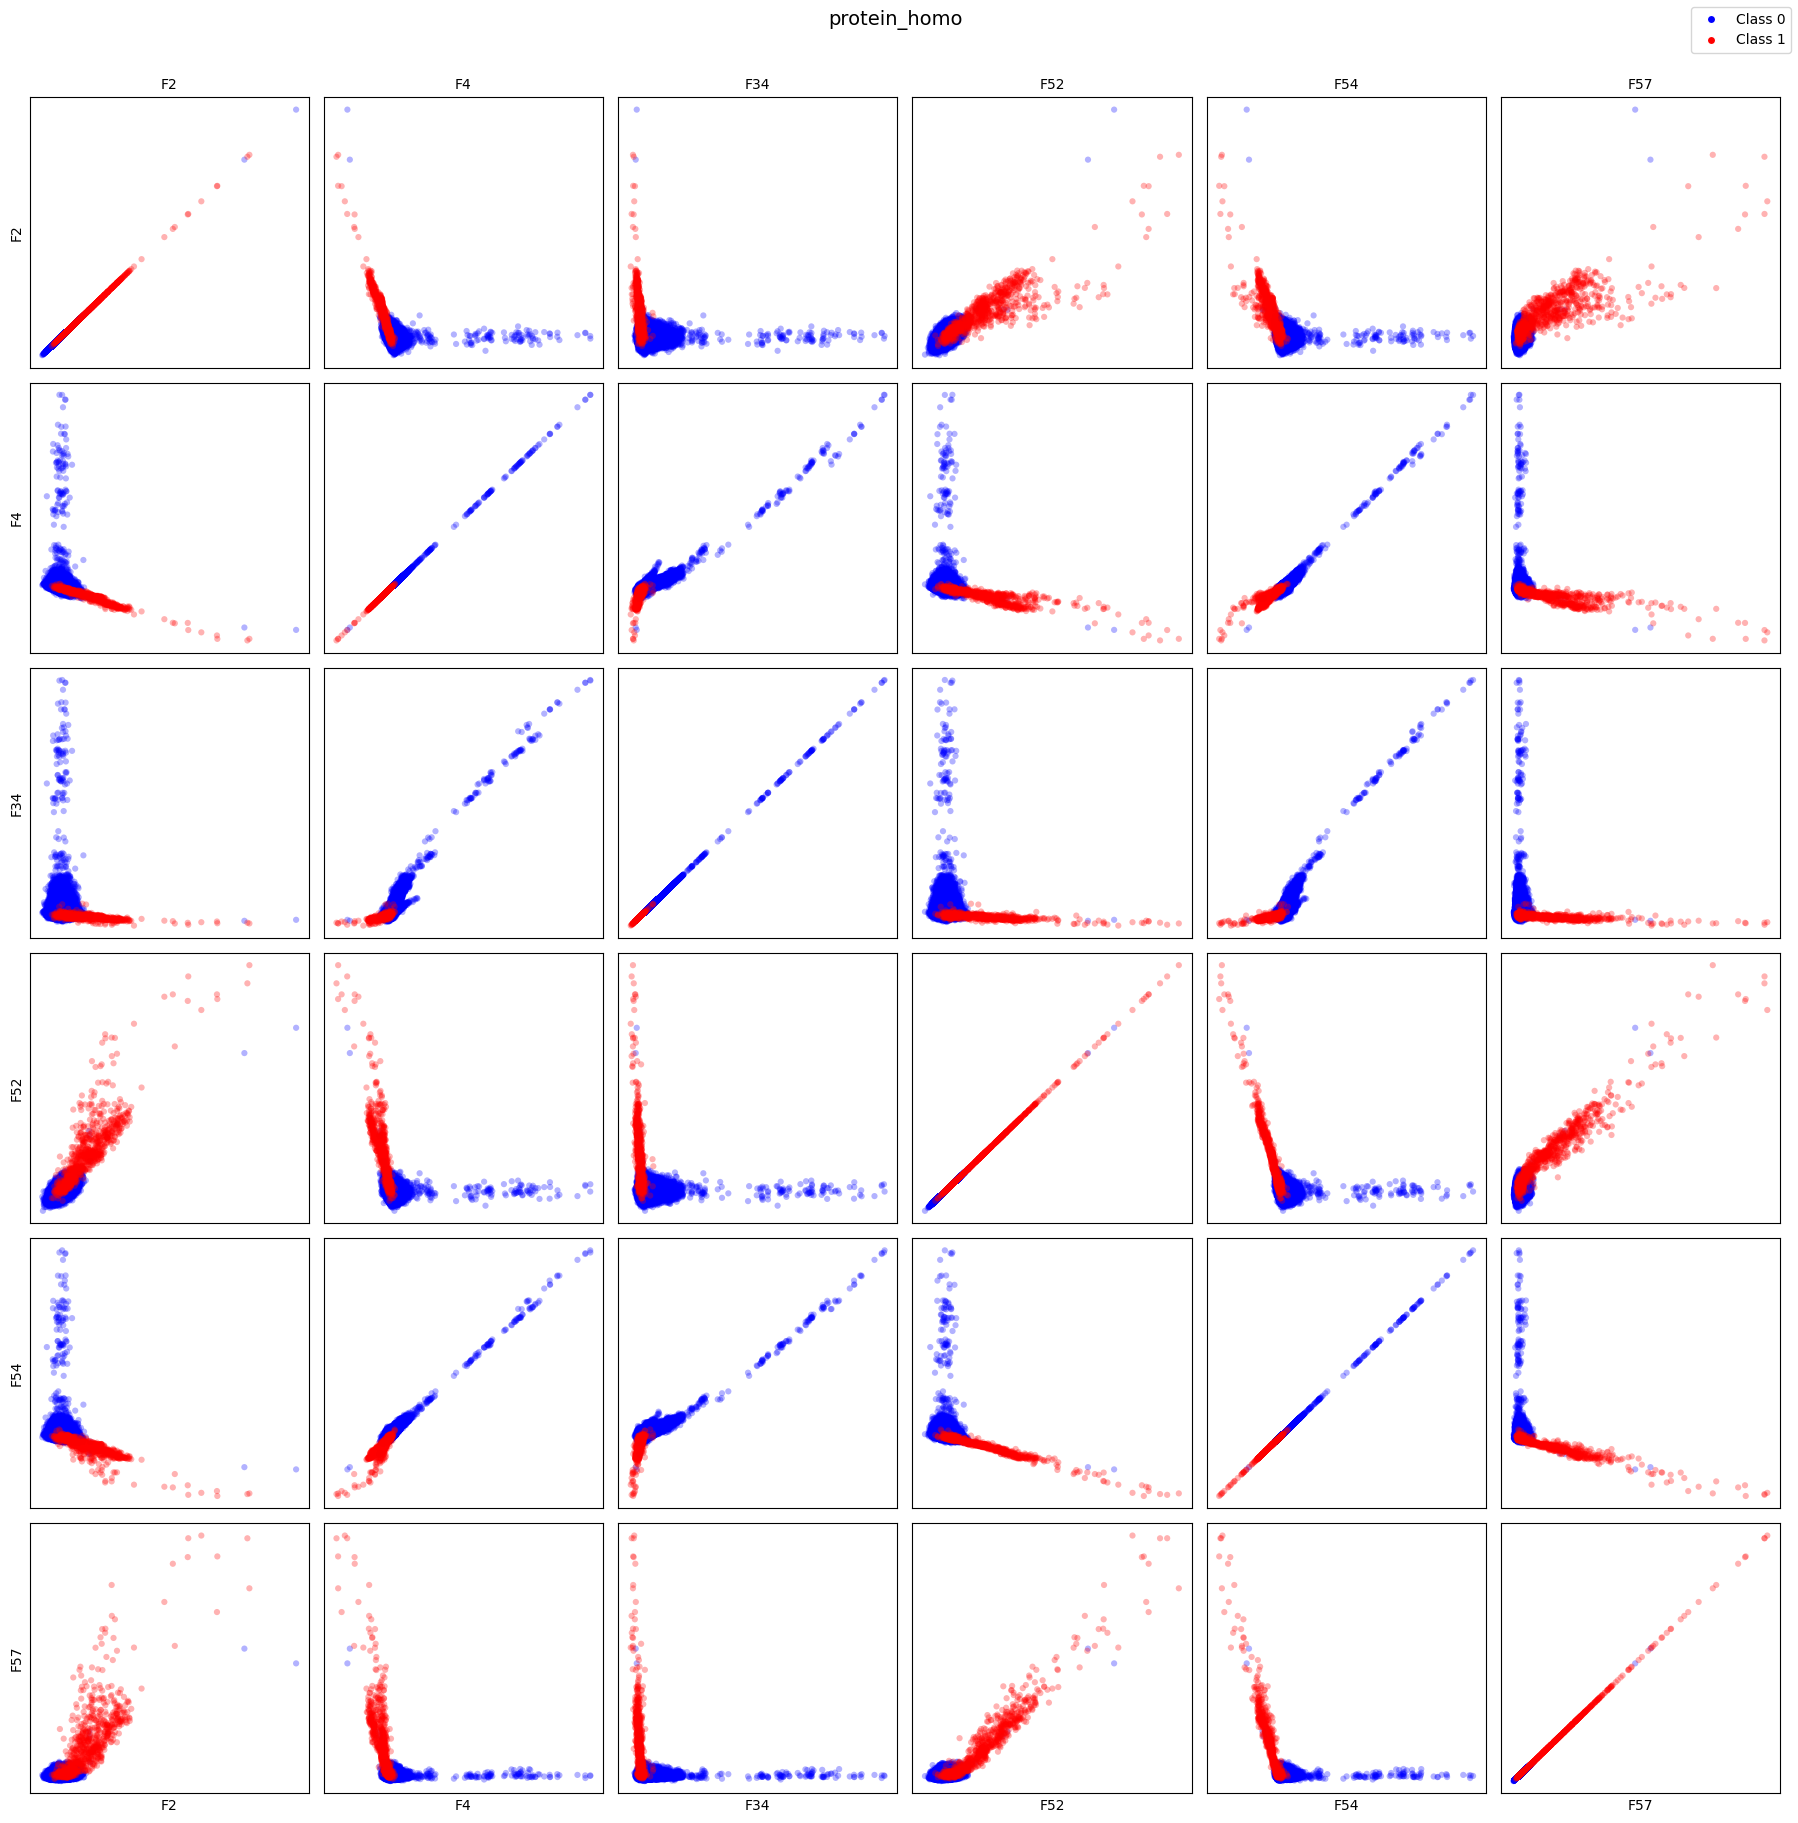

In [11]:
for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    
    # find good features
    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    if not good_features:
        print(f"{dataset}: no good features, skipping.")
        continue

    # Scatter plots
    feat_names = [f[0] for f in good_features]
    n = len(feat_names)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])
    for i, fi in enumerate(feat_names):
        for j, fj in enumerate(feat_names):
            ax = axes[i, j]
            for label, color in zip([0, 1], ["blue", "red"]):
                mask = y_train == label
                xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
                xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
                ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
            if i == n - 1:
                ax.set_xlabel(f"F{fj}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"F{fi}", fontsize=10)
            if i == 0:
                ax.set_title(f"F{fj}", fontsize=10)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
               for l, c in zip([0, 1], ["blue", "red"])]
    fig.legend(handles=handles, loc="upper right", fontsize=10)
    plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()